# Superstore Sales – Advanced Analysis

This notebook extends the initial exploratory data analysis by focusing on deeper business questions that require both SQL and Python. The goal is to understand how discounts impact profitability and to use SQL queries to extract structured insights from the dataset.

A combination of:
- SQL for targeted, query‑driven analysis  
- Python for visualization and statistical exploration  

This notebook demonstrates a more advanced analytical workflow suitable for real business intelligence tasks.

## 1. SQL Analysis

In this section, SQL is used to answer targeted business questions directly from the `superstore.db` database. SQL efficiently aggregates and filters data to uncover insights about profitability, product performance, and operational risks.

In [1]:
import sqlite3
import pandas as pd

# Load the dataset for Python analysis
df = pd.read_csv("../data/SampleSuperstore.csv")

# Connect to SQLite database for SQL analysis
conn = sqlite3.connect("../data/superstore.db")

### 1.1 Loss‑Making Transactions

This query identifies all transactions where the company lost money (i.e., Profit < 0).  
Analyzing loss‑making transactions helps uncover:

- products that are consistently unprofitable  
- discount levels that cause losses  
- regions or customer segments associated with negative profit  
- operational inefficiencies  

This is a critical analysis for improving profitability.

In [2]:
query_losses = """
SELECT *
FROM sales
WHERE Profit < 0
ORDER BY Profit ASC;
"""

losses = pd.read_sql_query(query_losses, conn)
losses.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Standard Class,Consumer,United States,Lancaster,Ohio,43130,East,Technology,Machines,4499.985,5,0.7,-6599.9780
1,Same Day,Corporate,United States,Burlington,North Carolina,27217,South,Technology,Machines,7999.980,4,0.5,-3839.9904
2,Standard Class,Consumer,United States,San Antonio,Texas,78207,Central,Office Supplies,Binders,2177.584,8,0.8,-3701.8928
3,Standard Class,Home Office,United States,Louisville,Colorado,80027,West,Technology,Machines,2549.985,5,0.7,-3399.9800
4,Standard Class,Corporate,United States,Chicago,Illinois,60653,Central,Office Supplies,Binders,1889.990,5,0.8,-2929.4845


**Insights:**

- The dataset contains multiple transactions where Profit < 0, indicating direct financial losses.
- Many of the loss‑making rows show high discount values, suggesting that aggressive discounting is a major driver of negative profit.
- Several product categories and sub‑categories appear repeatedly in the loss‑making list, indicating potential low‑margin or over‑discounted items.
- This raw output highlights the need for deeper analysis by category, region, and discount level to understand the root causes of these losses.

### 1.2 Total Profit by Region

This query shows which regions contribute the most profit.  
High‑profit regions may indicate strong customer demand or efficient operations, while low‑profit regions may require strategic review.

In [3]:
query_region = """
SELECT Region, SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

region_profit = pd.read_sql_query(query_region, conn)
region_profit

,Region,Total_Profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


**Insights:**

- The output clearly ranks regions by total profit, showing which geographic areas contribute the most to overall profitability.
- The top region(s) demonstrate strong demand and healthy margins, while the lowest‑profit region(s) may require operational or pricing review.
- This result provides a high‑level view of regional performance and can guide decisions around marketing, logistics, and resource allocation.

### 1.3 Top 10 Most Profitable Sub‑Categories

This query highlights the product sub‑categories that generate the highest profit.  
These items are strong candidates for promotional focus, inventory expansion, or targeted marketing.

In [4]:
query_subcat = """
SELECT "Sub-Category" AS SubCategory, SUM(Profit) AS Total_Profit
FROM sales
GROUP BY "Sub-Category"
ORDER BY Total_Profit DESC
LIMIT 10;
"""

subcat_profit = pd.read_sql_query(query_subcat, conn)
subcat_profit

,SubCategory,Total_Profit
0,Copiers,55617.8249
1,Phones,44515.7306
2,Accessories,41936.6357
3,Paper,34053.5693
4,Binders,30221.7633
5,Chairs,26590.1663
6,Storage,21278.8264
7,Appliances,18138.0054
8,Furnishings,13059.1436
9,Envelopes,6964.1767


**Insights:**

- The query returns the top 10 sub‑categories ranked by total profit, highlighting the strongest product lines in the business.
- These high‑profit sub‑categories may be ideal candidates for increased inventory, targeted promotions, or strategic investment.
- Sub‑categories not appearing in the top 10 may have lower margins or weaker demand, suggesting areas for further investigation.

## 2. Discount Analysis

Discounts are a major driver of customer purchasing behavior, but they can also reduce profitability.  
In this section, how average profit changes as discount levels increase is analysed.

Transactions are grouped by discount level and the average profit for each group is computed, and then the relationship is visualized.

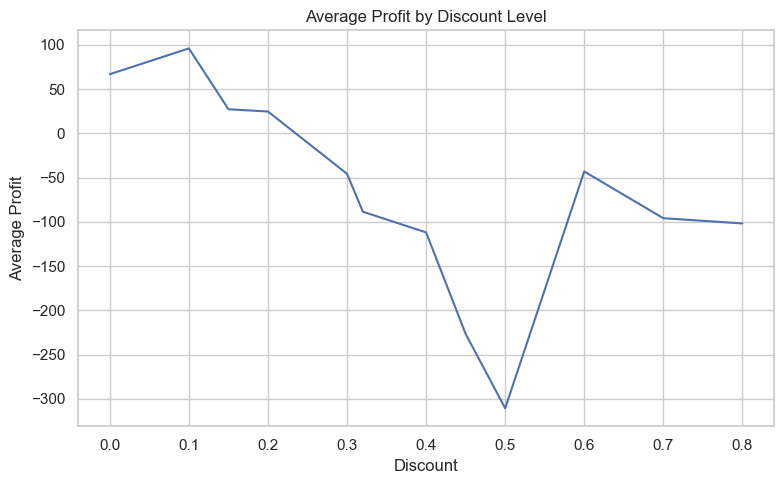

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=discount_profit, x='Discount', y='Profit')
plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.tight_layout()
plt.savefig("../visualizations/avg_profit_by_discount.png", dpi=300, bbox_inches='tight')
plt.show()

### Discount Insights

- Profit declines sharply as discount levels increase.
- Moderate discounts may still yield positive profit, but high discounts (40%+) often result in losses.
- This suggests the business should review its discount strategy, especially for low-margin products.

## 3. Conclusion

This advanced analysis highlights the value of combining SQL and Python for deeper business insights.

### Key Takeaways
- SQL queries provide fast, structured answers to business questions such as top categories, regions, and product groups.
- Discount analysis reveals a clear negative relationship between discount levels and profitability.
- High discount levels significantly erode profit, suggesting the need for a more controlled discounting strategy.

### Next Steps
- Build predictive models to estimate profit impact based on discount levels.
- Perform customer segmentation to identify high-value customer groups.
- Create dashboards (Tableau or Power BI) for executive reporting.